<div style="display:flex;align-items:center;justify-content:center;flex-direction:column;padding:18px 0;">
<h1 style="font-family: 'Segoe UI', Roboto, Arial; font-size:48px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">
LINEAR REGRESSION ASSIGNMENT
</h1>
<p style="margin:8px 0 0; color:#334155; font-size:16px;">A concise workbook covering how to build linear regression models, evaluate their performance, and interpret their coefficients to derive meaningful insights.</p>
</div>

---

<div style="display:flex;gap:12px;flex-wrap:wrap;align-items:center;">
<span style="background:#eef2ff;color:#3730a3;padding:6px 10px;border-radius:8px;font-weight:600;">📘 Basics</span>
<span style="background:#ecfdf5;color:#065f46;padding:6px 10px;border-radius:8px;font-weight:600;">⚙️ Examples</span>
<span style="background:#fff7ed;color:#92400e;padding:6px 10px;border-radius:8px;font-weight:600;">🔁 Exercises</span>
</div>


<details><summary><strong>Notebook info</strong></summary>

- **Author:** Sandipan Roy
- **Assignment Date:** 2026-02-16
- **Assignment Given By:** Karkavel Raja
- **Sections:** Importing Libraries · Data Loading · Data Preprocessing & Transformation Operations · Exploratory Data Analysis (EDA) · Fine-tuning and Optimization · Model Building · Model Evaluation · Model Optimization and Insights

</details>

---



<div style="display:flex;align-items:center;justify-content:center;flex-direction:column;padding:18px 0;">
<h2 style="font-family: 'Segoe UI', Roboto, Arial; font-size:38px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">Problem Statement:</h2>

---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">The objective of this assignment is to apply Simple Linear Regression and Multiple Linear Regression to predict outcomes based on given datasets. By exploring the datasets, students will learn how to build regression models, evaluate their performance, and interpret their coefficients to derive meaningful insights.</p>
</div>

---



<div style="display:flex;align-items:center;justify-content:center;flex-direction:column;padding:18px 0;">
<h2 style="font-family: 'Segoe UI', Roboto, Arial; font-size:38px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">Dataset for the Assignment:</h2>

---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">


-   [Medical Cost Personal Datasets | Kaggle](https://www.kaggle.com/datasets/mirichoi0218/insurance/data)
-   [Startup - Multilinear Regression Datasets | Kaggle](https://www.kaggle.com/datasets/karthickveerakumar/startup-logistic-regression/data)
-   [Calculate Concrete Strength Datasets | Kaggle](https://www.kaggle.com/datasets/prathamtripathi/regression-with-neural-networking/data)


</p>
</div>

---


<div style="display:flex;align-items:center;justify-content:center;flex-direction:column;padding:18px 0;">
<h2 style="font-family: 'Segoe UI', Roboto, Arial; font-size:38px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">Business Objective:</h2>

---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">

-   [Medical Cost Personal Datasets | Kaggle](https://www.kaggle.com/datasets/mirichoi0218/insurance/data) :- Insurance Charge Forecast by using Linear Regression</p>
</div>

---



<h3 style="font-family: 'Segoe UI', Roboto, Arial; font-size:28px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">1. Setup and Data Preparation:</h3>


---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Install the required libraries if not present.</u></li>
</ul>
</p>

---


In [1]:
!pip install scikit-learn
!pip install statsmodels


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Import all the required libraries and orchastrate control over the behaviour and display settings of pandas.</u></li>
</ul>
</p>

---


In [2]:
# Importing warning to disable runtime warnings
import warnings
# Warnings will appear only once
warnings.filterwarnings("ignore")

#=================================================================================

# Importing Numpy Library and aliasing it's name as np
import numpy as np
# Importing Pandas Library and aliasing it's name as pd
import pandas as pd
# Importing the Pyplot Interface from within the Matplotlib Library and aliasing it as plt
import matplotlib.pyplot as plt
# The above line of code can also be written as-
#    from matplotlib import pyplot as plt

# Importing Seaborn Library and aliasing it's name as sns
import seaborn as sns

# Importing the Plotly Express Interface from within the Plotly Library and aliasing it as px
import plotly.express as px


from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Importing the OLS (Ordinary Least Squares) method from the statsmodels
# library. The OLS method is used to fit a linear regression model to the data.
# The OLS method estimates the parameters of a linear regression model
# by minimizing the sum of squared residuals (the differences between
# observed and predicted values).
import statsmodels.api as sm
# Importing the anova_lm function from the statsmodels library to perform ANOVA (Analysis of Variance) tests
from statsmodels.stats.anova import anova_lm
# Importing the het_breuschpagan function from the statsmodels library
# to perform the Breusch-Pagan test for heteroscedasticity. The Breusch-Pagan
# test is used to determine whether the variance of the residuals from
# a regression model is constant (homoscedasticity) or varies with the
# level of the independent variable (heteroscedasticity).
from statsmodels.stats.diagnostic import het_breuschpagan
# Importing the durbin_watson and jarque_bera functions from the
# statsmodels library to perform the Durbin-Watson test for
# autocorrelation and the Jarque-Bera test for normality, respectively
from statsmodels.stats.stattools import durbin_watson, jarque_bera
# Importing the shapiro function from the scipy.stats library to
# perform the Shapiro-Wilk test for normality. The Shapiro-Wilk test is
# used to determine whether a sample of data comes from a normally
# distributed population. It tests the null hypothesis that the data is
# normally distributed. If the p-value is less than a chosen significance
# level (e.g., 0.05), then the null hypothesis is rejected,
# indicating that the data does not follow a normal distribution.
from scipy.stats import shapiro

#=================================================================================

# Unfolding hidden features if the cardinality is high
pd.set_option('display.max_columns', None)
# Unfolding the max feature width for better clearity
pd.set_option('display.max_colwidth', None)
# Unfolding hidden data points if the cardinality is high
pd.set_option('display.max_rows', None)
# Removing restriction over chained assignments operations
pd.set_option('mode.chained_assignment', None)
# To suppress scientific notation over exponential values
pd.set_option('display.float_format', lambda x: '%.5f' % x)

%matplotlib inline

---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Acquire data from datasource and bring it in-memory.</u></li>
</ul>
</p>

---


In [3]:
def acquire_data(url, sourceType="csv", verbose=False):
    """
    This function acquires data from the given URL and returns a DataFrame.

    Parameters:
    url (str): The URL from which to acquire the data.
    sourceType (str): The type of the data source (default is "csv").
    verbose (bool): If True, prints the shape of the DataFrame and its columns.

    Returns:
    pd.DataFrame: The acquired data as a DataFrame.
    """

    if sourceType.lower() != "csv":
        raise ValueError("Currently, only 'csv' source type is supported.")

    # Reading the CSV file from the provided URL
    df = pd.read_csv(url)

    # If verbose is True, print the shape of the DataFrame and its columns
    if verbose:
        print(f"DataFrame Shape: {df.shape}, i.e., {df.shape[0]} rows and {df.shape[1]} columns.")
        print(f"DataFrame Columns: {df.columns.tolist()}")

    return df

In [4]:
url = "https://raw.githubusercontent.com/Sandipan-Roy/sr/refs/heads/Dev/ML/Regression/Linear_Regression/data/raw/insurance.csv"

data = acquire_data(url, verbose=True)

DataFrame Shape: (1338, 7), i.e., 1338 rows and 7 columns.
DataFrame Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Analyze the aquired data and perform pre-profiling.</u></li>
</ul>
</p>

---


In [5]:
def analyze_data(df):
    """
    This function performs basic analysis on the given DataFrame and prints the results.

    Parameters:
    df (pd.DataFrame): The DataFrame to analyze.

    Returns:
    __dict__: A dictionary containing the results of the numerical columns and categorical columns list.
    """

    # Displaying the first 5 rows of the DataFrame
    print("First 5 rows of the DataFrame:")
    print(df.head())

    # Displaying the last 5 rows of the DataFrame
    print("\nLast 5 rows of the DataFrame:")
    print(df.tail())

    # Displaying the shape of the DataFrame
    print(f"\nShape of the DataFrame: {df.shape}")

    # Displaying the data types of each column
    print("\nData types of each column:")
    print(df.dtypes)

    #Displaying information about the DataFrame
    print("\nInformation about the DataFrame:")
    print(df.info())

    # Displaying the memory usage of the DataFrame
    print(f"\nMemory usage of the DataFrame: {(df.memory_usage(deep=True)).sum() / 1024:.2f} KB")  # Converting bytes to kilobytes
    print(((df.memory_usage(deep=True)) / 1024).round(2))  # Converting bytes to kilobytes

    # Listing numerical columns
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    # Listing categorical columns
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    print("\nWe have {} numerical features: {}".format(len(numerical_cols), numerical_cols))
    print("We have {} categorical features: {}".format(len(categorical_cols), categorical_cols))

    print("\nNumber of duplicated rows: {} ({}% of total rows)".format(
                    df.duplicated().sum(),
                    round(df.duplicated().sum() / df.shape[0] * 100, 2)
                    ))

    if len(numerical_cols) > 0:
      # Displaying summary statistics for numerical columns
      print("\nSummary statistics for numerical columns:")
      print(df.describe())

    if len(categorical_cols) > 0:
      # Displaying summary statistics for categorical columns
      print("\nSummary statistics for categorical columns:")
      print(df.describe(include=['object']))


    # Returning the list of numerical and categorical columns
    return {
        "numerical_columns": numerical_cols if len(numerical_cols) > 0 else None,
        "categorical_columns": categorical_cols if len(categorical_cols) > 0 else None
    }


In [6]:
dictColumns = analyze_data(data)
numerical_columns = dictColumns["numerical_columns"]
categorical_columns = dictColumns["categorical_columns"]

First 5 rows of the DataFrame:
   age     sex      bmi  children smoker     region     charges
0   19  female 27.90000         0    yes  southwest 16884.92400
1   18    male 33.77000         1     no  southeast  1725.55230
2   28    male 33.00000         3     no  southeast  4449.46200
3   33    male 22.70500         0     no  northwest 21984.47061
4   32    male 28.88000         0     no  northwest  3866.85520

Last 5 rows of the DataFrame:
      age     sex      bmi  children smoker     region     charges
1333   50    male 30.97000         3     no  northwest 10600.54830
1334   18  female 31.92000         0     no  northeast  2205.98080
1335   18  female 36.85000         0     no  southeast  1629.83350
1336   21  female 25.80000         0     no  southwest  2007.94500
1337   61  female 29.07000         0    yes  northwest 29141.36030

Shape of the DataFrame: (1338, 7)

Data types of each column:
age           int64
sex          object
bmi         float64
children      int64
smoker   

---
<a name = Section4></a>
### Data Acquisition Observations
---


The dataset consists of the information about people Medical-Insurance cost based on their age, gender, no. of children, bmi ratio, smoking habit and the region where they stay.


| Records | Features | Dataset Size |
| :-- | :-- | :-- |
| 1338 | 7 | 73.3+ KB |


| ID | Feature Name | Description of the feature | Data Type |
| :-- | :--| :--| :--|
|01| **age**   | Age of primary beneficiary                                    | int64 |
|02| **sex**      | Insurance contractor gender, female, male                 | object |
|03| **bmi**        | Body mass index, providing an understanding of body, weights that are relatively high or low relative to height, objective index of body weight (kg / m ^ 2) using the ratio of height to weight, ideally 18.5 to 24.9                            | float64 |
|04| **children**          | Number of children covered by health insurance / Number of dependents                                 | int64 |
|05| **smoker**           | Smoking habit                                  | object |
|06| **region**           | The beneficiary's residential area in the US, northeast, southeast, southwest, northwest.                                  | object |
|07| **charges**     | Individual medical costs billed by health insurance | float64 |


---

- Data types of all the features look appropriate.
- There are no missing values in any features.
- There is 1 duplicate row in the entire dataset.
- Memory usage of the DataFrame: 255.18 KB (approx)
- We have 4 numerical features: ['age', 'bmi', 'children', 'charges']
- We have 3 categorical features: ['sex', 'smoker', 'region']
- Primary beneficiary age is within the range of 18-64 and more than 50% of them are below 40yrs.
- Data has been taken for 4 distinct regions.
- 50% people are having either 0 or 1 dependant/children.


In [7]:
def get_proportion_of_categorical_values(df, column_name):
    """
    This function calculates the proportion of each unique value in a categorical column.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the categorical column.
    column_name (str): The name of the categorical column for which to calculate proportions.

    Returns:
    None (prints proportions for each column).
    """
    not_in_list2 = list(set(column_name) - set(df.columns))

    # Checking if the specified column is in the DataFrame
    if len(not_in_list2) > 0:
        raise ValueError(f"Column(s) '{', '.join(not_in_list2)}' not found in the DataFrame.")

    # Calculating the proportion of each unique value in the specified column
    for col in column_name:
        proportions = df[col].value_counts(normalize=True) * 100  # Multiplying by 100 to get percentages
        print(f"\nProportions for column '{col}' in %:")
        print(proportions)
        print("-" * 50)  # Adding a separator for better readability


In [8]:
get_proportion_of_categorical_values(data, categorical_columns)


Proportions for column 'sex' in %:
sex
male     50.52317
female   49.47683
Name: proportion, dtype: float64
--------------------------------------------------

Proportions for column 'smoker' in %:
smoker
no    79.52167
yes   20.47833
Name: proportion, dtype: float64
--------------------------------------------------

Proportions for column 'region' in %:
region
southeast   27.20478
southwest   24.28999
northwest   24.28999
northeast   24.21525
Name: proportion, dtype: float64
--------------------------------------------------


---
<a name = Section2></a>
#### Insights:

- For Gender column (sex), we are having approx 50.52% data for male and remaining 49.48% data for female.
- For Smoker column (smoker), data is imbalanced- 79.52% data is for non-smoker and remaining 20.48% data is for people with smoking habits.
- For Region column, data is more or less well balanced with southeast region data in higher side with i.e., 27% approx and remaining all the regions with 24% approx each.


<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Uni-variate Analysis.</u></li>
</ul>
</p>

---


In [9]:
total_datapoints = data.shape[0]
print(f"Total number of data points: {total_datapoints}")

Total number of data points: 1338


In [10]:
def plot_univariate_distribution(df, column, plot_type="histogram", plot_width=6, plot_height=4):
    """
    This function plots the univariate distribution of a specified column in the DataFrame.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the data.
    column (str): The name of the column to plot.
    plot_type (str): The type of plot to create ("histogram" or "boxplot" or "countplot").

    Returns:
    None
    """

    fig = plt.figure(figsize=(plot_width, plot_height))

    if plot_type != "boxplot":
        if plot_type == "histogram":
            ax = sns.histplot(df[column], kde=True, color='blue')
            plt.ylabel('Frequency')
        elif plot_type == "countplot":
            ax = sns.countplot(x=df[column], palette='magma')
            plt.ylabel('Count')
        else:
            raise ValueError("Invalid plot type. Use 'histogram' or 'boxplot' or 'countplot'.")

        for p in ax.patches:
            percentage = '{:.2f}%'.format(100 * p.get_height() / total_datapoints)
            x = p.get_x() + p.get_width()/5
            y = p.get_y() + p.get_height()
            ax.annotate(percentage, (x, y))

    else:
        ax = sns.boxplot(x=df[column], palette='magma')


    plt.title(f'{plot_type.capitalize()} of {column.capitalize()}')
    plt.xlabel(column.capitalize())
    plt.show()

In [11]:
numerical_columns, categorical_columns

(['age', 'bmi', 'children', 'charges'], ['sex', 'smoker', 'region'])

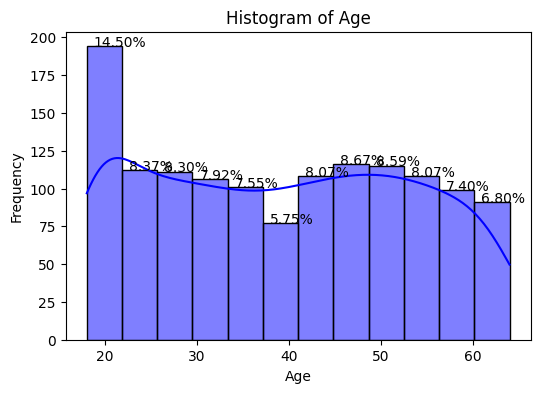

In [12]:
plot_univariate_distribution(data, column="age", plot_type="histogram")

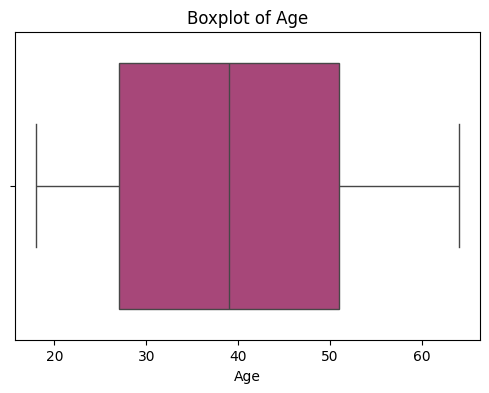

In [13]:
plot_univariate_distribution(data, column="age", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- About 14.5% data belongs to age group of 18-22yrs
- More than 50% people are below 40yrs

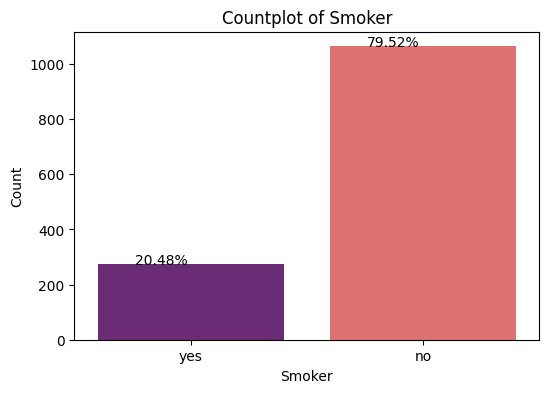

In [14]:
plot_univariate_distribution(data, column="smoker", plot_type="countplot")

---
<a name = Section2></a>
#### Insights:

- Approx 80% people don't smoke

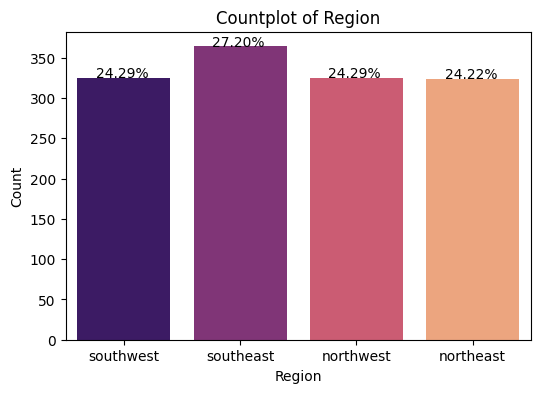

In [15]:
plot_univariate_distribution(data, column="region", plot_type="countplot")

---
<a name = Section2></a>
#### Insights:

- Region wise data is quiet well balanced.

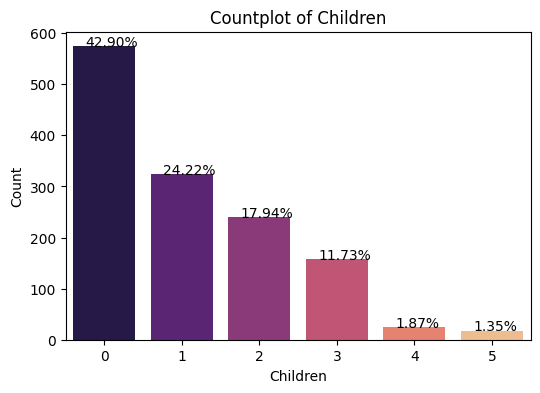

In [16]:
plot_univariate_distribution(data, column="children", plot_type="countplot")

---
<a name = Section2></a>
#### Insights:

- More than 42% people don't have any dependant/children
- Approx 54% people are having dependants/children ranging from 1-3
- Remaining people are having more than 3 dependants/children

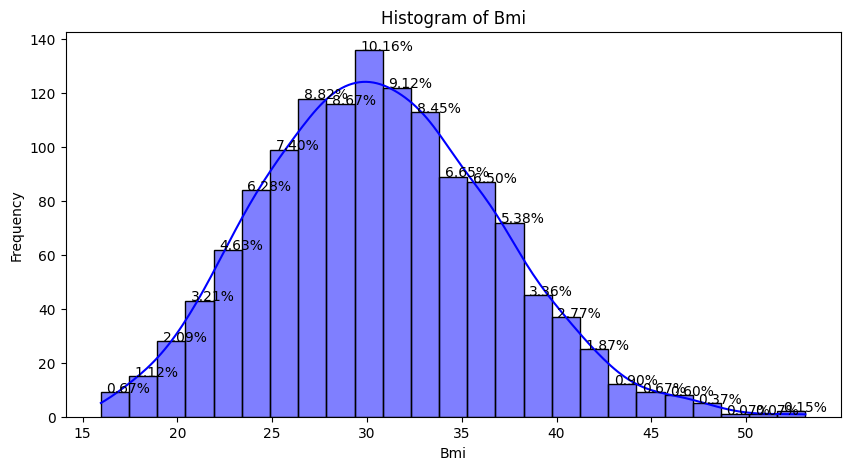

In [17]:
plot_univariate_distribution(data, column="bmi", plot_type="histogram", plot_width=10, plot_height=5)

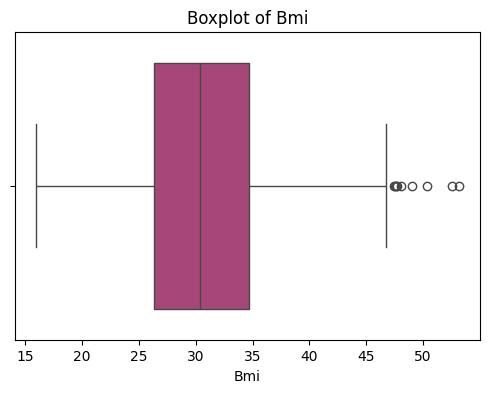

In [18]:
plot_univariate_distribution(data, column="bmi", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- We are having BMI with lower limit 15.96 and upper limit close to 53.13
- Median of the feature BMI is close to 30
- There are some outliers, and it's right skewed

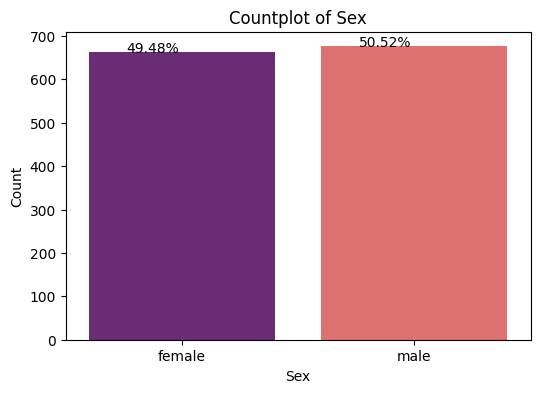

In [19]:
plot_univariate_distribution(data, column="sex", plot_type="countplot")

---
<a name = Section2></a>
#### Insights:

- Gender wise data is quiet well balanced.


<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Bi-variate Analysis.</u></li>
</ul>
</p>

---


In [20]:
def plot_bivariate_relationship(df, x_column, y_column, x_label=None, y_label=None, plot_type="scatter", plot_width=6, plot_height=4):
    """
    This function plots the bivariate relationship between two specified columns in the DataFrame.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the data.
    x_column (str): The name of the column to be plotted on the x-axis.
    y_column (str): The name of the column to be plotted on the y-axis.
    x_label (str): The label for the x-axis.
    y_label (str): The label for the y-axis.
    plot_type (str): The type of plot to create ("scatter" or "line" or "crosstab" or "boxplot").
    plot_width (int): The width of the plot in inches.
    plot_height (int): The height of the plot in inches.

    Returns:
    None
    """

    fig = plt.figure(figsize=(plot_width, plot_height))

    if plot_type == "scatter":
        ax = sns.scatterplot(x=df[x_column], y=df[y_column], color='blue')

        plt.title(f'Scatter Plot of {y_column.capitalize() if y_label is None else y_label.capitalize()} vs {x_column.capitalize() if x_label is None else x_label.capitalize()}')

    elif plot_type == "line":
        ax = sns.lineplot(x=df[x_column], y=df[y_column], color='blue')

        plt.title(f'Line Plot of {y_column.capitalize() if y_label is None else y_label.capitalize()} vs {x_column.capitalize() if x_label is None else x_label.capitalize()}')

    elif plot_type == "countplot":
        ax = sns.countplot(x=df[x_column], hue=df[y_column], palette='magma')

        for p in ax.patches:
            percentage = '{:.2f}%'.format(100 * p.get_height() / total_datapoints)
            x = p.get_x() + p.get_width()/5
            y = p.get_y() + p.get_height()
            ax.annotate(percentage, (x, y))

        plt.title(f'Count Plot of {y_column.capitalize() if y_label is None else y_label.capitalize()} vs {x_column.capitalize() if x_label is None else x_label.capitalize()}')
    elif plot_type == "crosstab":
        crosstab = pd.crosstab(df[x_column], df[y_column])
        ax = crosstab.plot(kind='bar', stacked=True, figsize=fig)

        for p in ax.patches:
            percentage = '{:.2f}%'.format(100 * p.get_height() / total_datapoints)
            x = p.get_x() + p.get_width()/5
            y = p.get_y() + p.get_height()
            ax.annotate(percentage, (x, y))

        plt.title(f'Cross-tabulation of {y_column.capitalize() if y_label is None else y_label.capitalize()} vs {x_column.capitalize() if x_label is None else x_label.capitalize()}')

    elif plot_type == "boxplot":
        ax = sns.boxplot(x=df[x_column], y=df[y_column])

        plt.title(f'Box Plot of {y_column.capitalize() if y_label is None else y_label.capitalize()} vs {x_column.capitalize() if x_label is None else x_label.capitalize()}')

    else:
        raise ValueError("Invalid plot type. Use 'scatter' or 'line'  or 'crosstab' or 'boxplot'.")


    plt.ylabel(y_column.capitalize() if y_label is None else y_label.capitalize())
    plt.xlabel(x_column.capitalize() if x_label is None else x_label.capitalize())

    plt.grid(visible=True)
    plt.show()

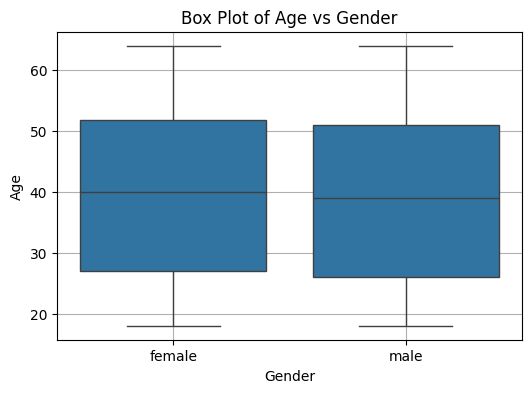

In [21]:
plot_bivariate_relationship(data, x_column="sex", y_column="age", plot_type="boxplot", x_label="Gender", y_label="Age")

---
<a name = Section2></a>
#### Insights:
- Average age of female is 40 whereas average age of male is close to 39

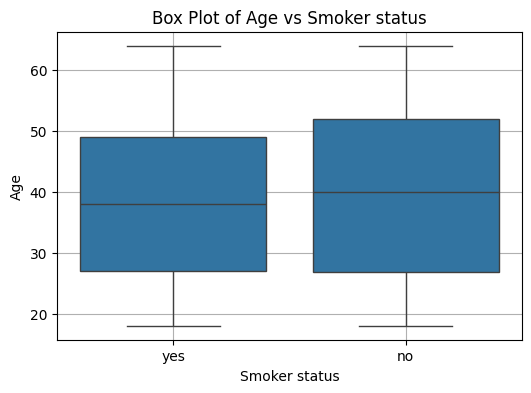

In [22]:
plot_bivariate_relationship(data, x_column="smoker", y_column="age", plot_type="boxplot", x_label="Smoker Status", y_label="Age")

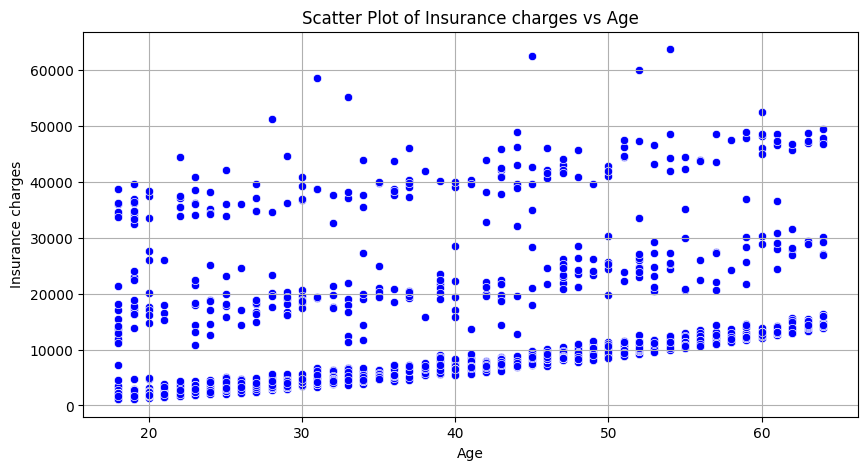

In [23]:
plot_bivariate_relationship(data, x_column="age",
                            y_column="charges", plot_type="scatter",
                            x_label="Age", y_label="Insurance Charges",
                            plot_width=10, plot_height=5)

---
<a name = Section2></a>
#### Insights:
- Insurance charge vs Age is scattered but not in a random way, rather it appears to be in a pattern of forming different groups.

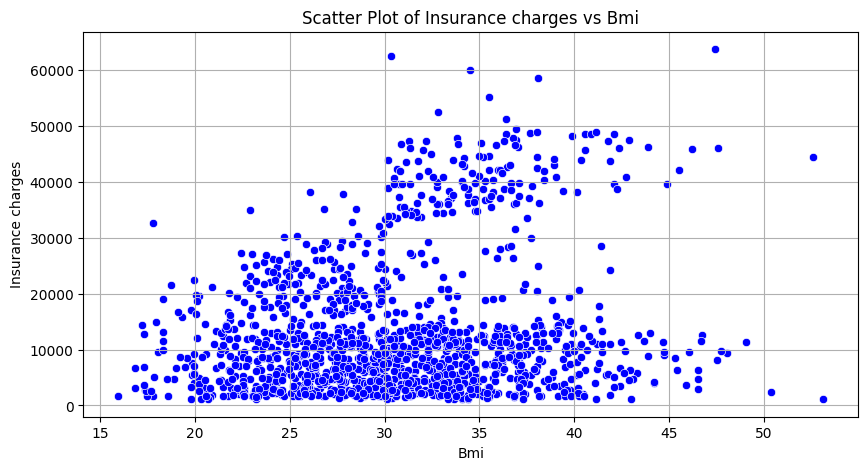

In [24]:
plot_bivariate_relationship(data, x_column="bmi",
                            y_column="charges", plot_type="scatter",
                            x_label="BMI", y_label="Insurance Charges",
                            plot_width=10, plot_height=5)

---
<a name = Section2></a>
#### Insights:
- BMI vs Charges is also scattered but comparatively in a quiet good shape

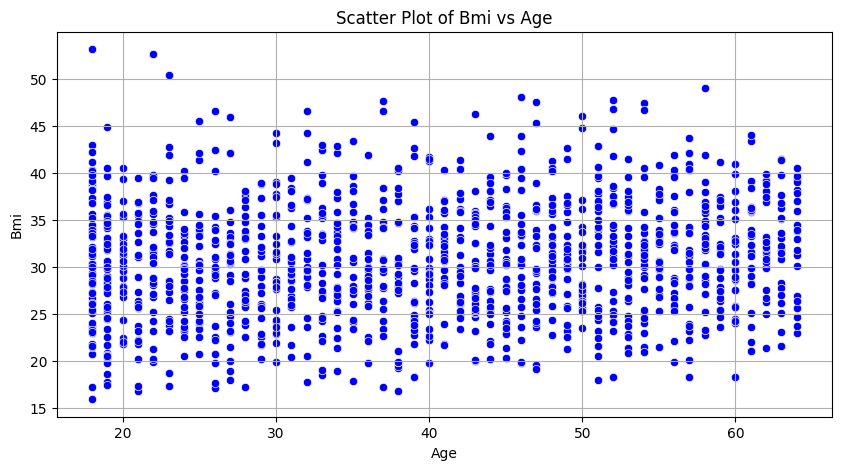

In [25]:
plot_bivariate_relationship(data, x_column="age",
                            y_column="bmi", plot_type="scatter",
                            x_label="Age", y_label="BMI",
                            plot_width=10, plot_height=5)

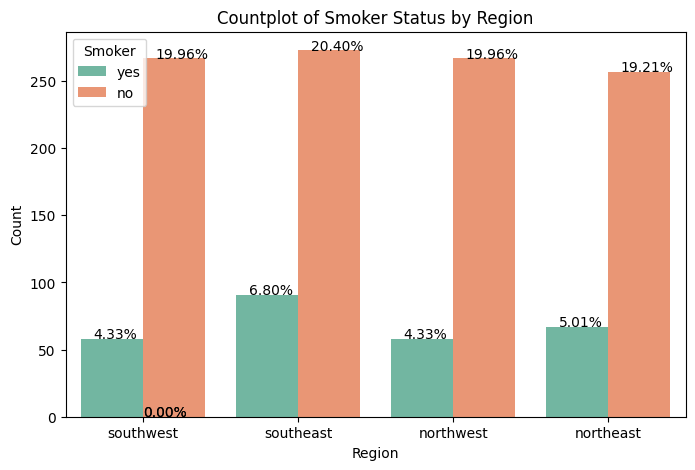

In [26]:
plt.figure(figsize=(8,5))
ax = sns.countplot(x='region', hue='smoker', data=data, palette='Set2')
plt.title('Countplot of Smoker Status by Region')
plt.xlabel('Region')
plt.ylabel('Count')

for p in ax.patches:
    percentage = '{:.2f}%'.format(100 * p.get_height() / total_datapoints)
    x = p.get_x() + p.get_width()/5
    y = p.get_y() + p.get_height()
    ax.annotate(percentage, (x, y))


plt.legend(title='Smoker')
plt.show()

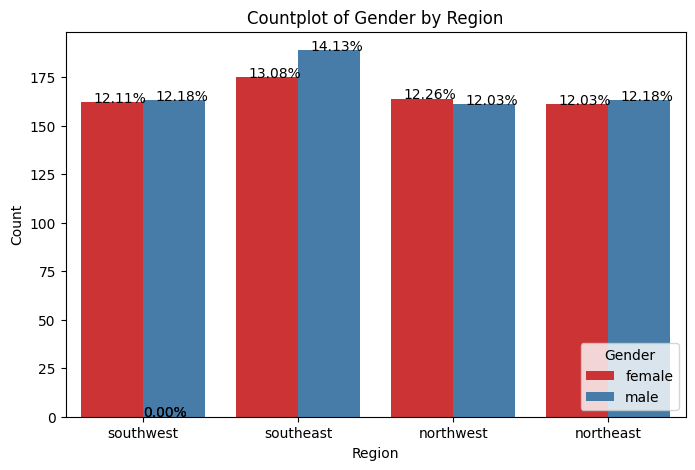

In [27]:
plt.figure(figsize=(8,5))
ax = sns.countplot(x='region', hue='sex', data=data, palette='Set1')
plt.title('Countplot of Gender by Region')
plt.xlabel('Region')
plt.ylabel('Count')

for p in ax.patches:
    percentage = '{:.2f}%'.format(100 * p.get_height() / total_datapoints)
    x = p.get_x() + p.get_width()/5
    y = p.get_y() + p.get_height()
    ax.annotate(percentage, (x, y))


plt.legend(title='Gender')
plt.show()

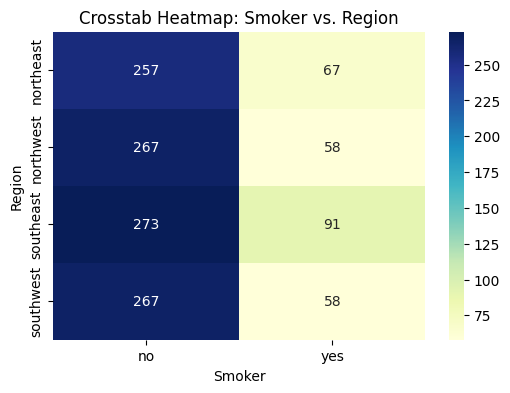

In [28]:
crosstab_smoker_region = pd.crosstab(data['region'], data['smoker'])
plt.figure(figsize=(6,4))
sns.heatmap(crosstab_smoker_region, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Crosstab Heatmap: Smoker vs. Region')
plt.xlabel('Smoker')
plt.ylabel('Region')
plt.show()

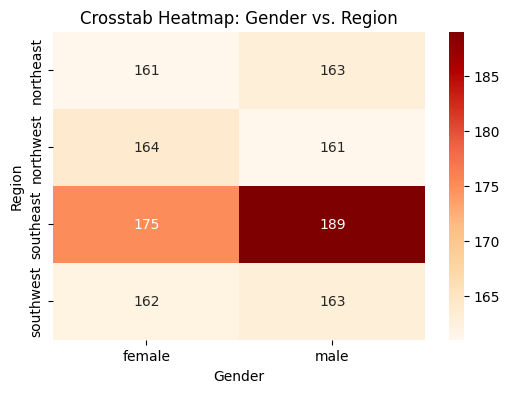

In [29]:
crosstab_sex_region = pd.crosstab(data['region'], data['sex'])
plt.figure(figsize=(6,4))
sns.heatmap(crosstab_sex_region, annot=True, cmap='OrRd', fmt='d')
plt.title('Crosstab Heatmap: Gender vs. Region')
plt.xlabel('Gender')
plt.ylabel('Region')
plt.show()


<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Multivariate Analysis: Pairplot & Correlation Matrix</u></li>
</ul>
</p>

---


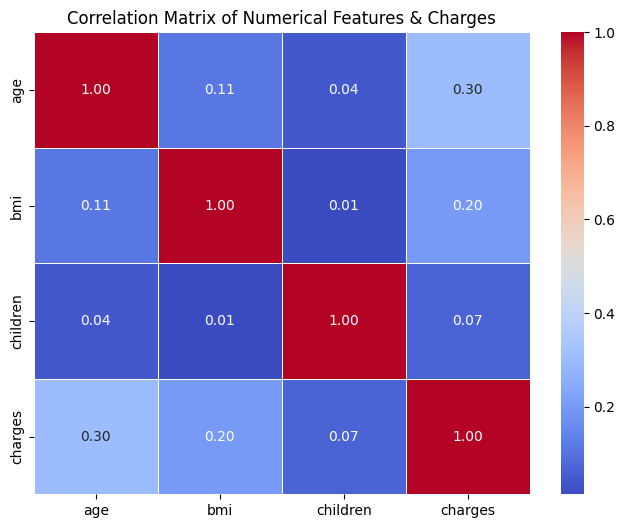

In [30]:
corr_matrix = data[['age', 'bmi', 'children', 'charges']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features & Charges')
plt.show()

---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Perform Data Wrangling.</u></li>
</ul>
</p>

---


In [31]:
def copy_dataframe(df):
    """
    This function creates and returns a copy of the given DataFrame
    to ensure that the original DataFrame remains unchanged during analysis.
    Also it removes duplicate data points if there are any in the DataFrame.

    Parameters:
    df (pd.DataFrame): The DataFrame to copy.

    Returns:
    pd.DataFrame: A copy of the input DataFrame.
    """
    df_copy = df.copy()

    # dropping duplicate data and keeping the first occurrence of each duplicate
    df_copy.drop_duplicates(inplace=True, keep='first')
    return df_copy

In [32]:
clean_data = copy_dataframe(data)

clean_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


In [33]:
def perform_feature_engineering(df):
  """
    This function performs meaningful extraction from the original dataframe
    and/or converts categorical feature into numerical counterparts by using OHE
    (One-Hot-Encoding) and Label Encoding. Drops the old features and returns
    a new copy of dataframe for further use.

    Parameters:
    df (pd.DataFrame): The DataFrame to perform feature engineering.

    Returns:
    pd.DataFrame: A DataFrame with new engineered features along with other features.
  """

  # performing one-hot-encoding for the 'sex' column
  df_dummies = pd.get_dummies(df['sex'], drop_first=True, dtype=np.uint8, prefix = 'Is')
  df = pd.concat([df, df_dummies], axis=1)
  print(df.head())

  # performing one-hot-encoding for the 'smoker' column
  df_dummies = pd.get_dummies(df['smoker'], drop_first=True, dtype=np.uint8)
  df_dummies.columns = ['Is_smoker']
  df = pd.concat([df, df_dummies], axis=1)
  print(df.head())

  # Create an instance of LabelEncoder
  le = LabelEncoder()

  df["region_encoded"] = le.fit_transform(df['region'])
  print(df.head())

  print(df["region_encoded"].unique())

  columns_to_drop =["sex", "smoker", "region"]
  df.drop(columns=columns_to_drop, axis=1, inplace= True)

  return df

In [34]:
clean_data = perform_feature_engineering(clean_data)
clean_data.head()

   age     sex      bmi  children smoker     region     charges  Is_male
0   19  female 27.90000         0    yes  southwest 16884.92400        0
1   18    male 33.77000         1     no  southeast  1725.55230        1
2   28    male 33.00000         3     no  southeast  4449.46200        1
3   33    male 22.70500         0     no  northwest 21984.47061        1
4   32    male 28.88000         0     no  northwest  3866.85520        1
   age     sex      bmi  children smoker     region     charges  Is_male  \
0   19  female 27.90000         0    yes  southwest 16884.92400        0   
1   18    male 33.77000         1     no  southeast  1725.55230        1   
2   28    male 33.00000         3     no  southeast  4449.46200        1   
3   33    male 22.70500         0     no  northwest 21984.47061        1   
4   32    male 28.88000         0     no  northwest  3866.85520        1   

   Is_smoker  
0          1  
1          0  
2          0  
3          0  
4          0  
   age     sex 

,age,bmi,children,charges,Is_male,Is_smoker,region_encoded
0,19,27.90000,0,16884.92400,0,1,3
1,18,33.77000,1,1725.55230,1,0,2
2,28,33.00000,3,4449.46200,1,0,2
3,33,22.70500,0,21984.47061,1,0,1
4,32,28.88000,0,3866.85520,1,0,1


In [35]:
dictColumns = analyze_data(clean_data)
new_numerical_columns = dictColumns["numerical_columns"]
new_categorical_columns = dictColumns["categorical_columns"]

First 5 rows of the DataFrame:
   age      bmi  children     charges  Is_male  Is_smoker  region_encoded
0   19 27.90000         0 16884.92400        0          1               3
1   18 33.77000         1  1725.55230        1          0               2
2   28 33.00000         3  4449.46200        1          0               2
3   33 22.70500         0 21984.47061        1          0               1
4   32 28.88000         0  3866.85520        1          0               1

Last 5 rows of the DataFrame:
      age      bmi  children     charges  Is_male  Is_smoker  region_encoded
1333   50 30.97000         3 10600.54830        1          0               1
1334   18 31.92000         0  2205.98080        0          0               0
1335   18 36.85000         0  1629.83350        0          0               2
1336   21 25.80000         0  2007.94500        0          0               3
1337   61 29.07000         0 29141.36030        0          1               1

Shape of the DataFrame: (1337, 

In [36]:
clean_data.describe()

,age,bmi,children,charges,Is_male,Is_smoker,region_encoded
count,1337.00000,1337.00000,1337.00000,1337.00000,1337.00000,1337.00000,1337.00000
mean,39.22214,30.66345,1.09574,13279.12149,0.50486,0.20494,1.51608
std,14.04433,6.10047,1.20557,12110.35966,0.50016,0.40381,1.10521
min,18.00000,15.96000,0.00000,1121.87390,0.00000,0.00000,0.00000
25%,27.00000,26.29000,0.00000,4746.34400,0.00000,0.00000,1.00000
50%,39.00000,30.40000,1.00000,9386.16130,1.00000,0.00000,2.00000
75%,51.00000,34.70000,2.00000,16657.71745,1.00000,0.00000,2.00000
max,64.00000,53.13000,5.00000,63770.42801,1.00000,1.00000,3.00000


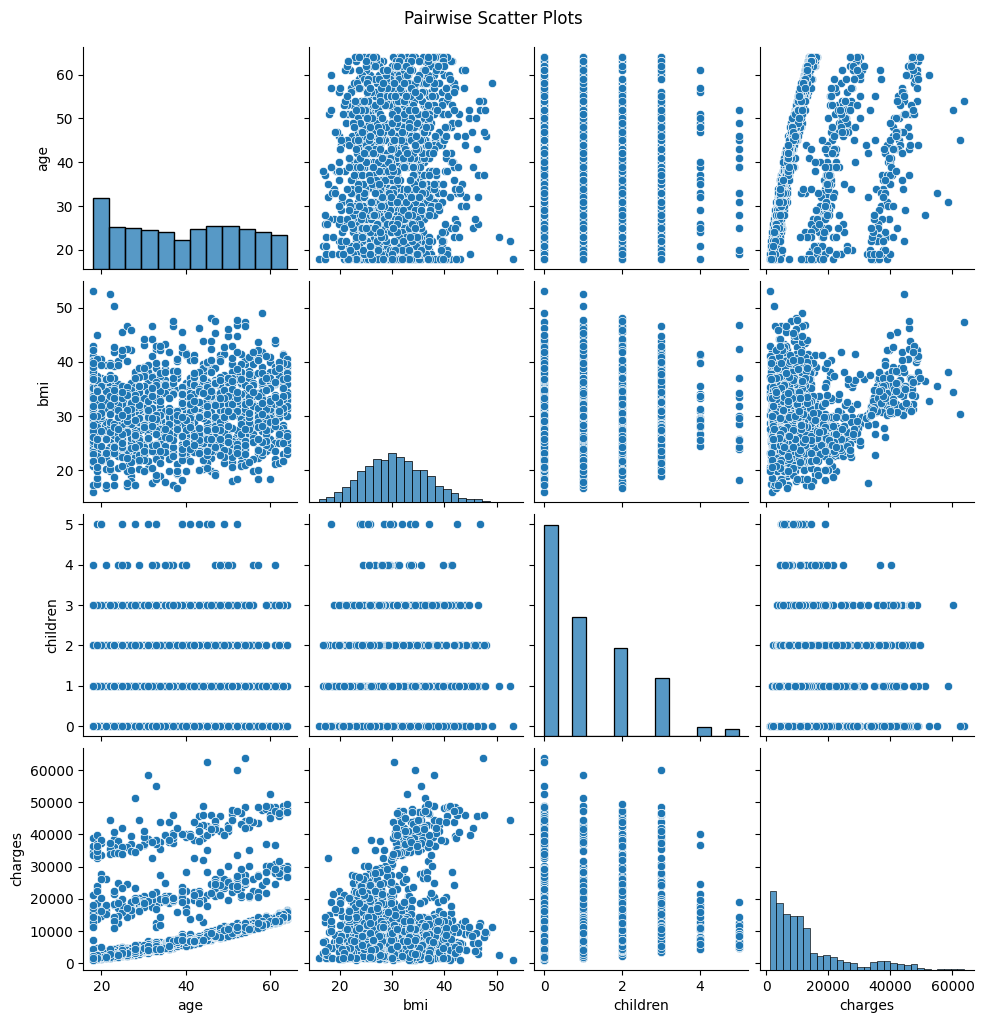

In [37]:
sns.pairplot(clean_data[numerical_columns])
plt.suptitle("Pairwise Scatter Plots", y=1.02)
plt.show()

In [38]:
new_numerical_columns

['age', 'bmi', 'children', 'charges', 'Is_male', 'Is_smoker', 'region_encoded']

Text(0.5, 0, 'Age')

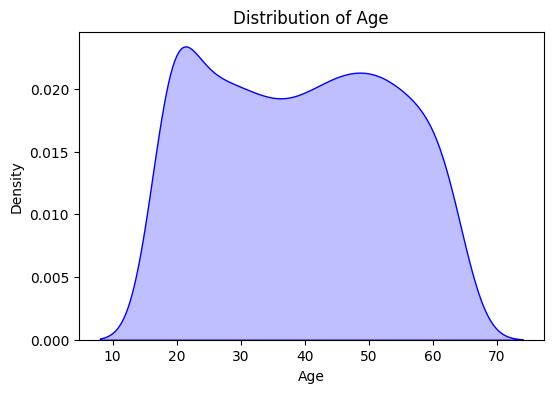

In [39]:
plt.figure(figsize=(6, 4))
sns.kdeplot(clean_data['age'], shade=True, color='blue')
plt.title('Distribution of Age')
plt.xlabel('Age')

Text(0.5, 1.0, 'Distribution of BMI')

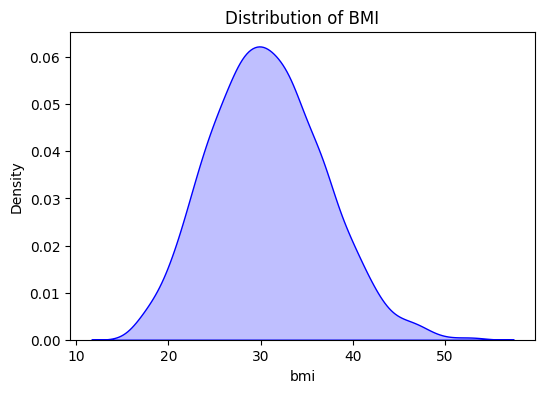

In [40]:
plt.figure(figsize=(6, 4))
sns.kdeplot(clean_data['bmi'], shade=True, color='blue')
plt.title('Distribution of BMI')

---
<a name = Section2></a>
#### Insights:
- BMI is right skewed, i.e., having some outliers in the upper-side or right-side of the median

Text(0.5, 0, 'Charges')

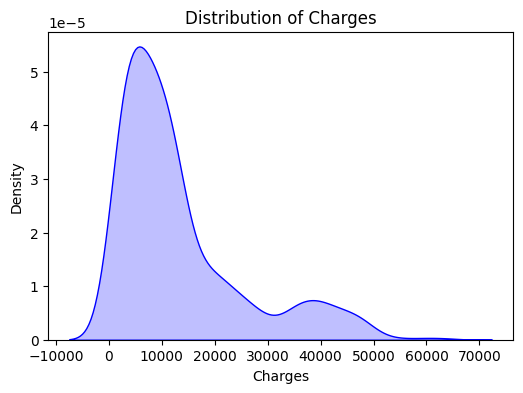

In [41]:
plt.figure(figsize=(6, 4))
sns.kdeplot(clean_data['charges'], shade=True, color='blue')
plt.title('Distribution of Charges')
plt.xlabel('Charges')

In [42]:
clean_data.corr(numeric_only=True)

,age,bmi,children,charges,Is_male,Is_smoker,region_encoded
age,1.00000,0.10934,0.04154,0.29831,-0.01981,-0.02559,0.00163
bmi,0.10934,1.00000,0.01275,0.19840,0.04640,0.00375,0.15757
children,0.04154,0.01275,1.00000,0.06739,0.01785,0.00733,0.01626
charges,0.29831,0.19840,0.06739,1.00000,0.05804,0.78723,-0.00655
Is_male,-0.01981,0.04640,0.01785,0.05804,1.00000,0.07660,0.00494
Is_smoker,-0.02559,0.00375,0.00733,0.78723,0.07660,1.00000,-0.00236
region_encoded,0.00163,0.15757,0.01626,-0.00655,0.00494,-0.00236,1.00000


In [43]:
for col in numerical_columns:
    Q1 = clean_data[col].quantile(0.25)
    Q3 = clean_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Find outliers
    outliers_low = clean_data[col] < lower_bound
    outliers_high = clean_data[col] > upper_bound

    # Replace outliers with nearest bound
    clean_data.loc[outliers_low, col] = lower_bound
    clean_data.loc[outliers_high, col] = upper_bound

    print(f"{col}: {outliers_low.sum() + outliers_high.sum()} outliers replaced")


age: 0 outliers replaced
bmi: 9 outliers replaced
children: 0 outliers replaced
charges: 139 outliers replaced


<h3 style="font-family: 'Segoe UI', Roboto, Arial; font-size:28px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">2. Simple Linear Regression:</h3>


In [44]:
X1 = clean_data[["age"]]
y1 = clean_data["charges"]

In [45]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

print(f"Training set size: {len(X1_train)} samples")
print(f"Testing set size: {len(X1_test)} samples")

Training set size: 1069 samples
Testing set size: 268 samples


In [46]:
slr_model = LinearRegression()
slr_model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [47]:
slr_model.fit(X= X1_train, y=y1_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


<h3 style="font-family: 'Segoe UI', Roboto, Arial; font-size:28px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">3. Multiple Linear Regression:</h3>


In [48]:
X = clean_data[["age","bmi","children","Is_smoker", "region_encoded", "Is_male"]]
y = clean_data["charges"]

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

Training set size: 1069 samples
Testing set size: 268 samples


In [50]:
scaler = StandardScaler()
col_for_analysis = ["age","bmi","children","Is_smoker", "region_encoded", "Is_male"]

X_train[col_for_analysis] = scaler.fit_transform(X_train[col_for_analysis])

X_test[col_for_analysis] = scaler.transform(X_test[col_for_analysis])

In [51]:
mlr_model = LinearRegression()
mlr_model.fit(X= X_train, y=y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


<h3 style="font-family: 'Segoe UI', Roboto, Arial; font-size:28px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">4. Model Evaluation:</h3>


In [52]:
y_hat = slr_model.predict(X=X1_test)

In [53]:
mean_absolute_error(y_pred=y_hat, y_true=y1_test)

8157.61337684643

In [54]:
r2_score(y_true=y1_test, y_pred=y_hat)

0.11314683625176913

In [55]:
y_predict = mlr_model.predict(X=X_test)

In [56]:
mean_absolute_error(y_pred=y_predict, y_true=y_test)

3149.8983211663312

In [57]:
r2_score(y_true=y_test, y_pred=y_predict)

0.8206978963475258

<h3 style="font-family: 'Segoe UI', Roboto, Arial; font-size:28px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">5. Residual Analysis:</h3>


- ### Analysis on SLR model

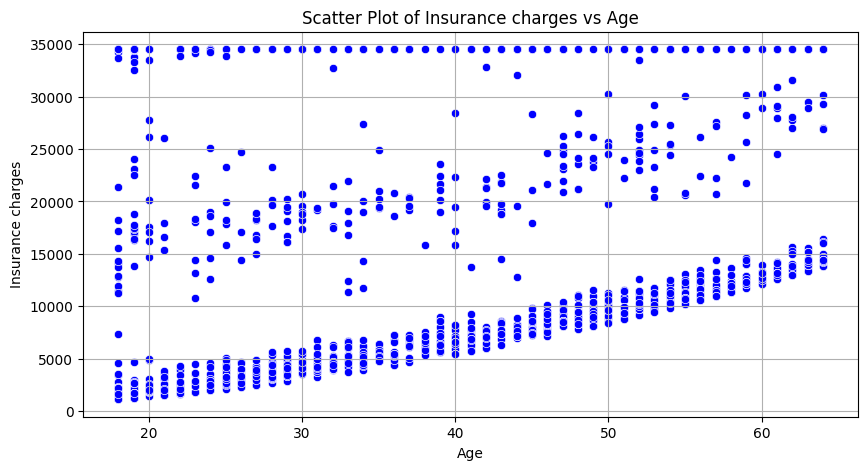

In [58]:
plot_bivariate_relationship(clean_data, x_column="age",
                            y_column="charges", plot_type="scatter",
                            x_label="Age", y_label="Insurance Charges",
                            plot_width=10, plot_height=5)

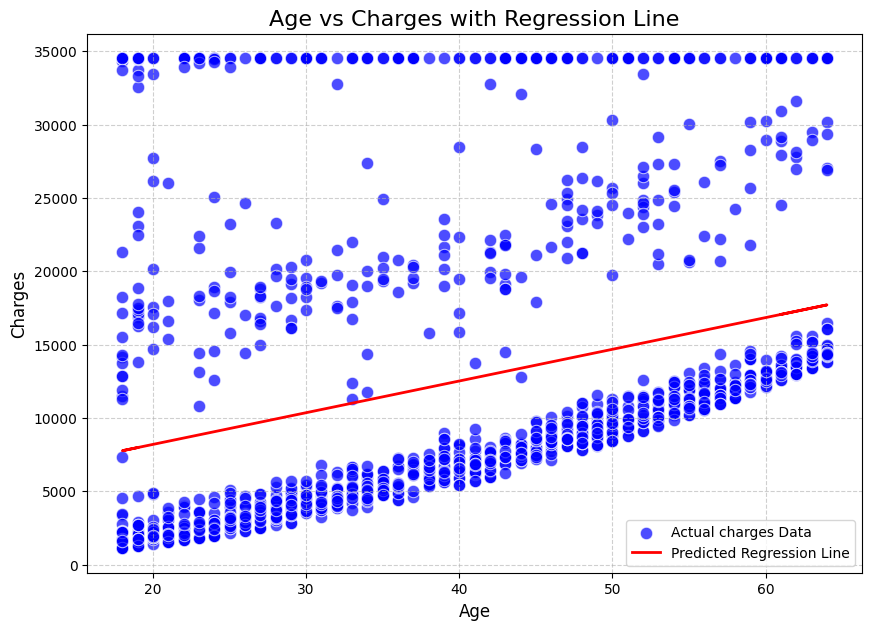

In [59]:
fig = plt.figure(figsize=(10, 7))
ax = sns.scatterplot(x=clean_data["age"], y=clean_data["charges"], color='blue', s=80, alpha=0.7, label='Actual charges Data')
plt.plot(X1, slr_model.predict(X1), color='red', linewidth=2, label='Predicted Regression Line')
plt.title('Age vs Charges with Regression Line', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Charges', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

---
<a name = Section2></a>
#### Insights:
---
Looking at the plot, we can observe that data is not randomly scattered rather it follows a pattern.

The SLR-model tends to underpredict for lower and higher charges, and overpredict for middle range charges.

This non-random pattern implies that a simple regression model based solely on 'age' is not adequate fit for the data for the prediction of charges.

In [60]:
# Fit OLS (statsmodels) so we can easily access residuals and summary
# for the simple linear regression model. The OLS method is used to
# fit a linear regression model to the data by minimizing the sum of
# squared residuals (the differences between observed and predicted values).
X1_const = sm.add_constant(X1)
model1 = sm.OLS(y1, X1_const).fit()

# Accessing the fitted values and residuals from the OLS model for the
# simple linear regression model. The fitted values are the predicted
# values of the dependent variable (charges) based on the independent
# variable (age) in the simple linear regression model. The
# residuals are the differences between the observed values of the
# dependent variable and the fitted values, which represent the errors
# in the predictions made by the model.
fitted_slr = model1.fittedvalues
residuals_slr = model1.resid


# Print summary and diagnostic test statistics for the simple linear
# regression model. The summary provides detailed information about
# the coefficients, standard errors, t-statistics, p-values,
# and overall model fit.
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.098
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     144.4
Date:                Sat, 07 Mar 2026   Prob (F-statistic):           1.17e-31
Time:                        11:15:03   Log-Likelihood:                -14164.
No. Observations:                1337   AIC:                         2.833e+04
Df Residuals:                    1335   BIC:                         2.834e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3621.5959    783.960      4.620      0.0

In [61]:
# Normality tests
# ==============================================================================
# The Jarque-Bera test is a statistical test that assesses whether the
# residuals of a regression model are normally distributed. It calculates
# a test statistic based on the skewness.
# The Shapiro-Wilk test is used to determine whether a sample of data
# comes from a normally distributed population. It tests the null
# hypothesis that the data is normally distributed. If the p-value is
# less than a chosen significance level (e.g., 0.05), then the null
# hypothesis is rejected, indicating that the data does not follow a
# normal distribution.
jb_stat_slr, jb_p_slr, jb_skew_slr, jb_kurtosis_slr = jarque_bera(residuals_slr)
sh_stat_slr, sh_p_slr = shapiro(residuals_slr)
print("\nNormality tests:")
print(f"Jarque-Bera stat={jb_stat_slr:.4f}, p-value={jb_p_slr:.4g}")
print(f"Shapiro-Wilk stat={sh_stat_slr:.4f}, p-value={sh_p_slr:.4g}")


Normality tests:
Jarque-Bera stat=503.9110, p-value=3.777e-110
Shapiro-Wilk stat=0.6961, p-value=8.376e-44


---
<a name = Section2></a>
#### Insights:
---

The normality tests (Jarque-Bera and Shapiro-Wilk) have been executed successfully on the residuals of the Simple Linear Regression model. The results indicate the following:

- Jarque-Bera Test: The statistic is 503.9110 with a p-value of 3.777e-110.
- Shapiro-Wilk Test: The statistic is 0.6961 with a p-value of 8.376e-44.

Since both p-values are extremely small (much less than the common significance level of 0.05), we reject the null hypothesis that the residuals are normally distributed. This suggests that the residuals of your Simple Linear Regression model are not normally distributed, which can be an indication that the model might not be the best fit for the data or that some assumptions of linear regression are violated.

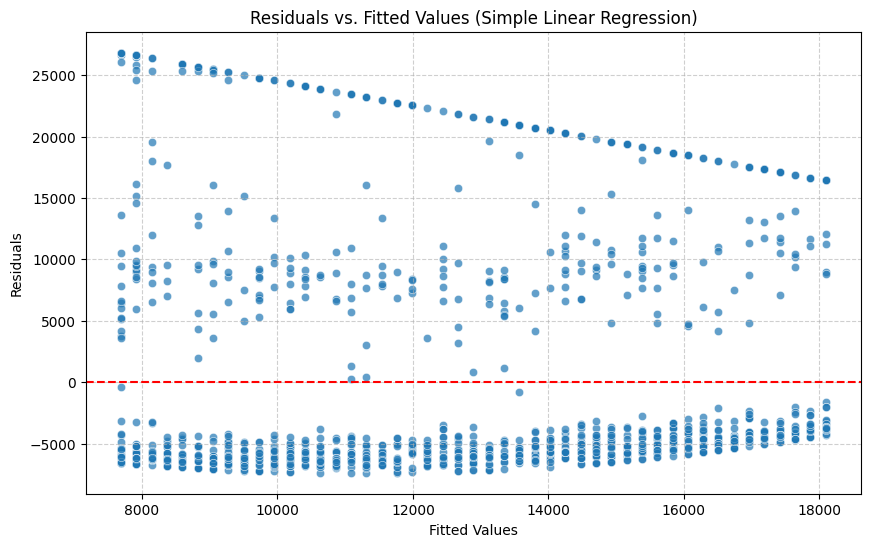

In [62]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_slr, y=residuals_slr, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Fitted Values (Simple Linear Regression)')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

---
<a name = Section2></a>
#### Insights:
---
This plot helps in understanding the model's assumption about the errors.

This scatter plot of residuals versus fitted values for the SLR-model (age vs charges) is crucial for the accessing the assumptions of linearity, independence and homoscedasticity in our model.

Looking at the plot, we can observe that the residuals are not randomly scattered around the zero line; instead, there appears to be a clear pattern, specifically a funnel shape, which widens as the fitted values increases.

Additionally, there might be a slight upward curve in the distribution of residuals, suggesting that the linear model might not fully capture the underlying relationship between 'age' and 'charges'. The model tends to underpredict for lower and higher charges, and overpredict for the middle range charges.

This non-random pattern implies that the assumption of linearity is violated and that a simple linear model based solely on 'age' is not adequate fit for the data to predict 'charges'.

In [63]:
# Homoscedasticity (Breusch-Pagan)
# ==============================================================================
# The Breusch-Pagan test is used to determine whether the variance of the
# residuals from a regression model is constant (homoscedasticity) or
# varies with the level of the independent variable (heteroscedasticity).
# Heteroscedasticity occurs when the variability of the errors (residuals)
# in a regression model is not constant across all levels of the independent
# variables. In simpler terms, the spread of the residuals is unequal across the
# range of predicted values.
# The test returns a Lagrange multiplier statistic, its p-value, an F-statistic,
# and its p-value. If the p-value is less than a chosen significance level
# (e.g., 0.05), then the null hypothesis of homoscedasticity is rejected,
# indicating that the variance of the residuals is not constant and may be
# related to the independent variable.
# The Breusch-Pagan test is performed by regressing the squared residuals
# from the original regression model on the independent variables. The test
# statistic is calculated based on the explained variance of this auxiliary
# regression.
bp_test_slr = het_breuschpagan(residuals_slr, X1_const)
# The bp_test_slr variable contains the results of the Breusch-Pagan test
# for the simple linear regression model. It includes the Lagrange multiplier
# statistic, its p-value, the F-statistic, and its p-value, which are used
# to assess the presence of heteroscedasticity in the residuals of the model.
# The Lagrange multiplier statistic tests whether the variance of the residuals
# is related to the independent variable (age). The p-value associated
# with the Lagrange multiplier statistic indicates the significance of this
# relationship. The F-statistic tests the overall significance of the
# auxiliary regression, and its p-value indicates whether the variance of
# the residuals is significantly related to the independent variable.
# If either p-value is less than the chosen significance level (e.g., 0.05),
# then the null hypothesis of homoscedasticity is rejected,
# suggesting that the variance of the residuals is not constant and may be
# related to the independent variable.
bp_labels_slr = ["Lagrange multiplier stat", "LM p-value", "F-stat", "F p-value"]
# The bp_labels_slr variable contains the labels for the results of the
# Breusch-Pagan test for the simple linear regression model. These labels
# correspond to the values in the bp_test_slr variable, which include the
# Lagrange multiplier statistic, its p-value, the F-statistic, and its p-value.
# The labels are used to identify and interpret the results of the
# Breusch-Pagan test when printed or displayed.
print("\nBreusch-Pagan test for Simple Linear Regression model:")
for lab, val in zip(bp_labels_slr, bp_test_slr):
    print(f"{lab}: {val:.4f}")


Breusch-Pagan test for Simple Linear Regression model:
Lagrange multiplier stat: 21.5476
LM p-value: 0.0000
F-stat: 21.8678
F p-value: 0.0000


---
<a name = Section2></a>
#### Insights:
---
The Breusch-Pagan test is used to detect heteroscedasticity(non-constant variance of errors) in a regression model. Here's a breakdown of the output:

- *Lagrange Multiplier stat (LM stat):* 21.5476
  
  This is the test statistic for the Breusch-Pagan test. A larger value generally indicates stronger evidence against homoscedasticity.

  Generally min value = 0 and max value = n, where n is the sample size.

- *F-stat:* 21.8678

  This is the F-statistic from the auxiliary regression used in the Breusch-Pagan test. It essentially test the overall significance of the relationship between the squared residuals and the independent variable.

- *LM p-value:* 0.0000

  This is the p-value associated with the Lagrange Multiplier statistic.

- *F p-value:* 0.0000

  This is the p-value associated with the F-statistic.

Both the LM p-value and F p-value are zero, which indicates a very strong rejection of the null hypothesis that the variance of the residuals is constant.

This also confirms the visual observation from the residuals vs fitted values plot: the Simple Linear Regression model exhibits significant heteroscedasticity. This means that the standard errors of our regression coefficients may be biased, affecting the reliability of our t-statistics, p-values and confidence intervals.

In [64]:
# Independence (Durbin-Watson)
# ==============================================================================
# The Durbin-Watson test is a statistical test used to detect the presence of
# autocorrelation (serial correlation) in the residuals of a regression model.
# The test statistic ranges from 0 to 4, where a value of 2 indicates no
# autocorrelation, values less than 2 indicate positive autocorrelation, and
# values greater than 2 indicate negative autocorrelation. If the test statistic
# is significantly different from 2, it suggests that the residuals are not
# independent and may be correlated with each other, which can violate the
# assumptions of linear regression and affect the validity of the model's
# inferences.
dw_slr = durbin_watson(residuals_slr)
# The dw_slr variable contains the Durbin-Watson test statistic for the simple
# linear regression model. This statistic is used to assess the presence of
# autocorrelation in the residuals of the model.
print(f"\nDurbin-Watson: {dw_slr:.4f} (values near 2 indicate no autocorrelation)")



Durbin-Watson: 2.0341 (values near 2 indicate no autocorrelation)


---
<a name = Section2></a>
#### Insights:
---
Since your Durbin-Watson statistic is 2.0341, which is very close to 2, it suggests that there is no significant autocorrelation in the residuals of your Simple Linear Regression model. This is a good sign, as it means the assumption of independence of errors (a key assumption in linear regression) is likely met.

- ### Analysis on MLR model

In [65]:
# Fit OLS (statsmodels) so we can easily access residuals and summary
# for the multiple linear regression model. The OLS method is used to fit a
# linear regression model to the data by minimizing the sum of squared
# residuals (the differences between observed and predicted values).
# The OLS method estimates the parameters of a linear regression model by
# minimizing the sum of squared residuals, which allows us to assess the
# significance of each independent variable in the multiple linear regression
# model and evaluate the overall fit of the model to the data.
X_const_mlr = sm.add_constant(X)
model_mlr = sm.OLS(y, X_const_mlr).fit()

# Accessing the fitted values and residuals from the OLS model for the
# multiple linear regression model. The fitted values are the predicted values
# of the dependent variable (charges) based on the independent variables
# (age, bmi, children, Is_smoker, region_encoded, Is_male) in the multiple
# linear regression model.
# The residuals are the differences between the observed values of the dependent
# variable and the fitted values, which represent the errors in the predictions
# made by the model.
fitted_mlr = model_mlr.fittedvalues
residuals_mlr = model_mlr.resid

# Print summary and diagnostic test statistics for the multiple linear
# regression model. The summary provides detailed information about the
# coefficients, standard errors, t-statistics, p-values, and overall model
# fit for the multiple linear regression model, allowing us to evaluate
# the significance of each independent variable and the overall performance of
# the model in explaining the variation in the dependent variable (charges).
print(model_mlr.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.748
Model:                            OLS   Adj. R-squared:                  0.746
Method:                 Least Squares   F-statistic:                     656.3
Date:                Sat, 07 Mar 2026   Prob (F-statistic):               0.00
Time:                        11:15:03   Log-Likelihood:                -13313.
No. Observations:                1337   AIC:                         2.664e+04
Df Residuals:                    1330   BIC:                         2.668e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const          -7086.7628    810.110     -8.

---
<a name = Section2></a>
#### Insights:
---

- The Multiple Linear Regression model is a much better fit for the data than the Simple Linear Regression model, explaining significantly more variance in insurance charges (R-squared increased from 0.098 to 0.748).

- age, bmi, children, Is_smoker, and region_encoded are all statistically significant predictors of insurance charges.

- Is_smoker is by far the strongest predictor, having a very large positive coefficient, indicating that smokers pay substantially more.

- Is_male (gender) does not appear to be a significant predictor once other factors are considered.

- There is no significant autocorrelation among the residuals (Durbin-Watson close to 2).

- The high Condition Number (298) suggests potential multicollinearity. This means some of our independent variables might be correlated with each other, which can make it difficult to determine the individual impact of each predictor precisely.


In [66]:
# Normality tests
# ==============================================================================
# The Jarque-Bera test is a statistical test that assesses whether the
# residuals of a regression model are normally distributed. It calculates a test
# statistic based on the skewness and kurtosis of the residuals. The
# Shapiro-Wilk test is used to determine whether a sample of data comes
# from a normally distributed population. It tests the null hypothesis that
# the data is normally distributed. If the p-value is less than a chosen
# significance level (e.g., 0.05), then the null hypothesis is rejected,
# indicating that the data does not follow a normal distribution. These tests
# are important for validating the assumptions of linear regression and
# ensuring that the residuals of the model are normally distributed, which can
# affect the validity of the model's inferences and predictions.
jb_stat_mlr, jb_p_mlr, jb_skew_mlr, jb_kurtosis_mlr  = jarque_bera(residuals_mlr)
sh_stat_mlr, sh_p_mlr = shapiro(residuals_mlr)
print("\nNormality tests:")
print(f"Jarque-Bera stat={jb_stat_mlr:.4f}, p-value={jb_p_mlr:.4g}")
print(f"Shapiro-Wilk stat={sh_stat_mlr:.4f}, p-value={sh_p_mlr:.4g}")



Normality tests:
Jarque-Bera stat=1712.1980, p-value=0
Shapiro-Wilk stat=0.8089, p-value=4.444e-37


---
<a name = Section2></a>
#### Insights:
---
- Jarque-Bera Test:

    - Statistic (jb_stat_mlr): 1712.1980
    - p-value (jb_p_mlr): 0.0000

- Shapiro-Wilk Test:

    - Statistic (sh_stat_mlr): 0.8089
    - p-value (sh_p_mlr): 4.444e-37

For both tests, the p-values (0.0000 and 4.444e-37 respectively) are extremely small (much less than the common significance level of 0.05). This leads us to reject the null hypothesis for both tests, which states that the residuals are normally distributed.

In other words, both the Jarque-Bera and Shapiro-Wilk tests strongly indicate that the residuals of your Multiple Linear Regression model are not normally distributed.

Though the MLR model shows a significantly better fit (higher R-squared) compared to the SLR model, the non-normality of residuals suggests that one of the key assumptions of Ordinary Least Squares (OLS) regression is violated.

In [67]:
# Homoscedasticity (Breusch-Pagan)
# ==============================================================================
# The Breusch-Pagan test is used to determine whether the variance of the
# residuals from a regression model is constant (homoscedasticity) or varies
# with the level of the independent variable (heteroscedasticity). The test
# returns a Lagrange multiplier statistic, its p-value, an F-statistic, and
# its p-value. If the p-value is less than a chosen significance level
# (e.g., 0.05), then the null hypothesis of homoscedasticity is rejected,
# indicating that the variance of the residuals is not constant and may be
# related to the independent variables. The Breusch-Pagan test is performed
# by regressing the squared residuals from the original regression model on
# the independent variables. The test statistic is calculated based on the
# explained variance of this auxiliary regression, and it helps to assess
# whether the variance of the residuals is related to the independent variables
# in the multiple linear regression model.
bp_test_mlr = het_breuschpagan(residuals_mlr, X_const_mlr)
bp_labels_mlr = ["Lagrange multiplier stat", "LM p-value", "F-stat", "F p-value"]
print("\nBreusch-Pagan test:")
for lab, val in zip(bp_labels_mlr, bp_test_mlr):
    print(f"{lab}: {val:.4f}")


Breusch-Pagan test:
Lagrange multiplier stat: 26.2595
LM p-value: 0.0002
F-stat: 4.4409
F p-value: 0.0002


---
<a name = Section2></a>
#### Insights:
---
Both the Lagrange Multiplier p-value and the F p-value are highly significant, indicating that the residuals of our Multiple Linear Regression model exhibit heteroscedasticity. This means the variance of the errors is not constant across all levels of our independent variables. As discussed before, heteroscedasticity affects the standard errors of our coefficients, making our t-statistics and p-values less reliable for making inferences about individual predictors.

In [68]:
# Independence (Durbin-Watson)
# ==============================================================================
# The Durbin-Watson test is a statistical test used to detect the presence of
# autocorrelation (serial correlation) in the residuals of a regression model.
# The test statistic ranges from 0 to 4, where a value of 2 indicates no
# autocorrelation, values less than 2 indicate positive autocorrelation, and
# values greater than 2 indicate negative autocorrelation. If the test statistic
# is significantly different from 2, it suggests that the residuals are not
# independent and may be correlated with each other, which can violate the
# assumptions of linear regression and affect the validity of the model's
# inferences.
dw_mlr = durbin_watson(residuals_mlr)
print(f"\nDurbin-Watson: {dw_mlr:.4f} (values near 2 indicate no autocorrelation)")



Durbin-Watson: 2.1007 (values near 2 indicate no autocorrelation)


---
<a name = Section2></a>
#### Insights:
---
Since your Durbin-Watson statistic is 2.1007, which is very close to 2, it suggests that there is no significant autocorrelation in the residuals of your Multi-Linear Regression model. This is a good sign, as it means the assumption of independence of errors (a key assumption in linear regression) is likely met.

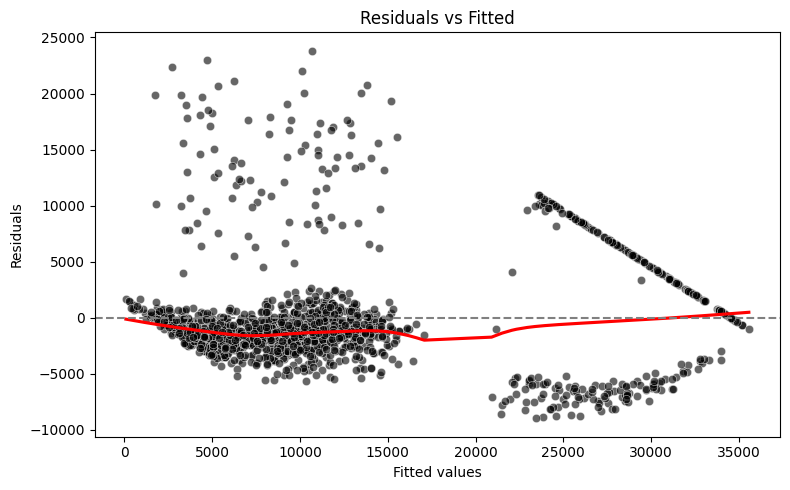

In [69]:
# Residuals vs Fitted (linearity + homoscedasticity)
plt.figure(figsize=(8,5))
sns.scatterplot(x=fitted_mlr, y=residuals_mlr, color='k', alpha=0.6)
sns.regplot(x=fitted_mlr, y=residuals_mlr, lowess=True, scatter=False, line_kws={"color":"red"})
plt.axhline(0, linestyle='--', color='grey')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.tight_layout()
plt.show()

---
<a name = Section2></a>
#### Insights:
---
- The red line not being perfectly flat around zero suggests that the model might not be fully capturing all the linear relationships in the data, or there could be some non-linearity that the model isn't accounting for.
- The increasing spread of residuals confirms the heteroscedasticity detected by the Breusch-Pagan test. This means the assumption of constant variance of errors is violated. As previously discussed, this can lead to inefficient coefficient estimates and incorrect standard errors, affecting the reliability of our statistical inferences.

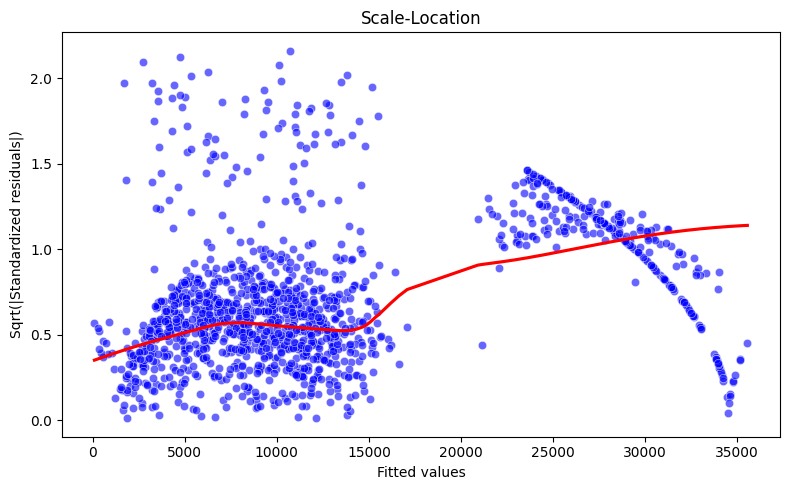

In [70]:
# Scale-Location plot (sqrt standardized residuals vs fitted) to check spread
std_resid = residuals_mlr / np.std(residuals_mlr)
sqrt_std = np.sqrt(np.abs(std_resid))
plt.figure(figsize=(8,5))
sns.scatterplot(x=fitted_mlr, y=sqrt_std, color='b', alpha=0.6)
sns.regplot(x=fitted_mlr, y=sqrt_std, scatter=False, lowess=True, line_kws={"color":"red"})
plt.xlabel('Fitted values')
plt.ylabel('Sqrt(|Standardized residuals|)')
plt.title('Scale-Location')
plt.tight_layout()
plt.show()

---
<a name = Section2></a>
#### Insights:
---
- The red line is not flat; it clearly shows an upward trend. This indicates that the spread (or variability) of the residuals increases as the fitted values increase. The points are also more spread out on the right side of the plot compared to the left.
- This pattern confirms the presence of heteroscedasticity, which we also observed in the 'Residuals vs. Fitted' plot and was statistically confirmed by the Breusch-Pagan test. The increasing spread means that the errors of our model are not uniformly distributed; instead, they become larger for higher predicted values of insurance charges. This violation of homoscedasticity has implications for the validity of our statistical inferences, as the standard errors of our coefficients will be biased.

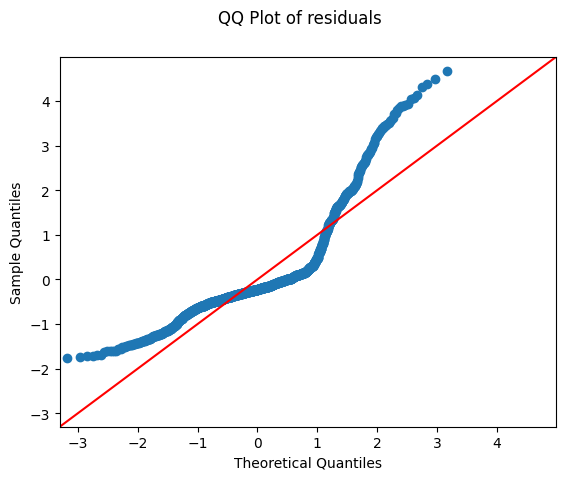

In [71]:
# QQ-plot for normality
fig = sm.qqplot(residuals_mlr, line='45', fit=True)
fig.suptitle('QQ Plot of residuals')
plt.show()

---
<a name = Section2></a>
#### Insights:
---
- The residuals form an 'S' shape, curving away from the line at both the lower and upper ends.
- This deviation strongly indicates that the residuals are not normally distributed. The 'S' shape typically suggests that the distribution of our residuals has heavier tails (more outliers) and possibly skewness compared to a normal distribution. This observation is consistent with the results from the Jarque-Bera and Shapiro-Wilk tests, which also rejected the null hypothesis of normality for these residuals.

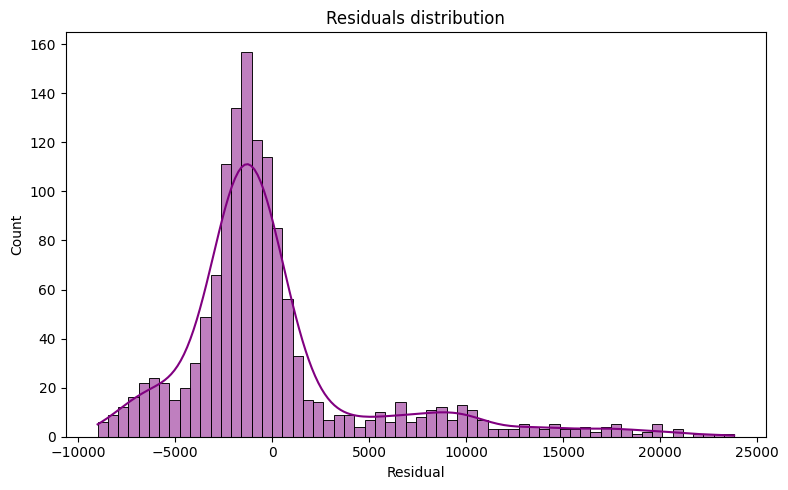

In [72]:
# Histogram of residuals
plt.figure(figsize=(8,5))
sns.histplot(residuals_mlr, kde=True, color='purple')
plt.title('Residuals distribution')
plt.xlabel('Residual')
plt.tight_layout()
plt.show()

<h3 style="font-family: 'Segoe UI', Roboto, Arial; font-size:28px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">6. Model Optimization:</h3>


---
<a name = Section4></a>
### **Hypothesis:**
---

- **Null Hypothesis (H0):** Each feature’s coefficient is zero; the feature does not significantly predict the target variable (charges).

- **Alternative Hypothesis (H1):** Each feature’s coefficient is not zero; the feature significantly predicts the target variable.

---
Interpretation:
---
- If p-value < 0.05, reject the null hypothesis for that feature; it is statistically significant
- If p-value >= 0.05, fail to reject the null hypothesis; the feature is not significant

In [73]:
# Checking for significance of each feature using Individual t-tests.
# The t-test is the "micro" view. When we want to decide if a single specific feature
# is statistically significant in predicting the target variable, we can look at
# the p-value associated with that feature's coefficient in the regression model.
# If the p-value is less than a chosen significance level (commonly 0.05),
# we can conclude that the feature is statistically significant in predicting the target variable.

# Defining the target variable (y) and the feature variables (X)
y=clean_data['charges']
# Add a constant (intercept) - statsmodels needs this explicitly
X=sm.add_constant(clean_data[["age", "bmi", "Is_male", "Is_smoker", "region_encoded", "children"]])

model_full = sm.OLS(y, X).fit()
print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.748
Model:                            OLS   Adj. R-squared:                  0.746
Method:                 Least Squares   F-statistic:                     656.3
Date:                Sat, 07 Mar 2026   Prob (F-statistic):               0.00
Time:                        11:15:04   Log-Likelihood:                -13313.
No. Observations:                1337   AIC:                         2.664e+04
Df Residuals:                    1330   BIC:                         2.668e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const          -7086.7628    810.110     -8.

---
Insight:
---

- Features with low p-values (typically bmi, age, Is_smoker, children) are strong predictors of charges.
- Feature with high p-value (Is_male) shows multi-colinearity, hence cannot be used in our prediction model.

In [74]:
# Define features (X) and log-transformed target (y) for the new MLR model
X_new = clean_data[["age","bmi","children","Is_smoker", "region_encoded"]]
y_new = clean_data["charges"]


In [75]:
# Split data into training and testing sets
X_new_train, X_new_test, y_new_train, y_new_test = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

print(f"New MLR Training set size: {len(X_new_train)} samples")
print(f"New MLR Testing set size: {len(X_new_test)} samples")

New MLR Training set size: 1069 samples
New MLR Testing set size: 268 samples


In [76]:
# Scale the features
scaler_new = StandardScaler()
col_for_analysis_new = ["age","bmi","children","Is_smoker", "region_encoded"]

X_new_train[col_for_analysis_new] = scaler_new.fit_transform(X_new_train[col_for_analysis_new])
X_new_test[col_for_analysis_new] = scaler_new.transform(X_new_test[col_for_analysis_new])


In [77]:
# Fit the new Multiple Linear Regression model
mlr_model_new = LinearRegression()
mlr_model_new.fit(X=X_new_train, y=y_new_train)
print(mlr_model_new)

LinearRegression()


In [78]:
# Make predictions and evaluate the new model
y_new_predict = mlr_model_new.predict(X=X_new_test)

mae_new = mean_absolute_error(y_pred=y_new_predict, y_true=y_new_test)
r2_new = r2_score(y_true=y_new_test, y_pred=y_new_predict)

print(f"New MLR Mean Absolute Error: {mae_new}")
print(f"New MLR R-squared: {r2_new}")

New MLR Mean Absolute Error: 3150.347987731263
New MLR R-squared: 0.8208029422455034


In [87]:
print(mlr_model_new.coef_)
print(mlr_model_new.intercept_)

[3139.52830599 1262.24771845  555.11554038 7847.03356553 -221.08553942]
12349.049137249767


---
<a name = Section2></a>
#### Insights:
---
- So our Multi Linear equation becomes:

    - y = 3139.52830599 * X1 + 1262.24771845 * X2 + 555.11554038 * X3 + 7847.03356553 * X4 - 221.08553942 * X5 + 12349.049137249767

        OR

    - Charges = 3139.52830599 * age + 1262.24771845 * bmi + 555.11554038 * children + 7847.03356553 * Is_smoker - 221.08553942 * region_encoded + 12349.049137249767
